In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [93]:
dfc = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Customers.csv')
dfc.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,I74lXDOfoqsp,6020,goiania,GO
1,47TuLHF2s7X5,23020,viamao,RS
2,dQ0dqI8Qwlj8,75094,campinas,SP
3,iQCmWhNkIczb,89284,santana de parnaiba,SP
4,Dp2g6JH8tO5Z,39810,aripuana,MT


In [94]:
dfc.isnull().sum()

customer_id                 0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [95]:
dfc.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               38279 non-null  str  
 1   customer_zip_code_prefix  38279 non-null  int64
 2   customer_city             38279 non-null  str  
 3   customer_state            38279 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.1 MB


In [96]:
dfc = dfc.drop_duplicates()

In [97]:
dfi = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_OrderItems.csv')
dfi.head()

,order_id,product_id,seller_id,price,shipping_charges
0,u6rPMRAYIGig,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90
1,ohY8f4FEbX19,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28
2,I28liQek73i2,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11
3,bBG1T89mlY8W,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05
4,CYxJJSQS8Lbo,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41


In [98]:
dfi.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          38279 non-null  str    
 1   product_id        38279 non-null  str    
 2   seller_id         38279 non-null  str    
 3   price             38279 non-null  float64
 4   shipping_charges  38279 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.8 MB


In [99]:
dfi.isnull().sum()

order_id            0
product_id          0
seller_id           0
price               0
shipping_charges    0
dtype: int64

In [100]:
dfi.shape

(38279, 5)

In [101]:
dfi = dfi.drop_duplicates()

In [102]:
dfi.shape

(38279, 5)

In [103]:
dfo = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Orders.csv')
dfo.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30


In [104]:
dfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   order_id                  38279 non-null  str  
 1   customer_id               38279 non-null  str  
 2   order_purchase_timestamp  38279 non-null  str  
 3   order_approved_at         38272 non-null  str  
dtypes: str(4)
memory usage: 3.4 MB


In [105]:
dfo['order_purchase_timestamp'] = pd.to_datetime(dfo['order_purchase_timestamp'])
dfo['order_approved_at'] = pd.to_datetime(dfo['order_approved_at'])

In [106]:
dfo.shape

(38279, 4)

In [107]:
dfo = dfo.drop_duplicates()

In [108]:
dfo.shape

(38279, 4)

In [109]:
dfo.isnull().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at           7
dtype: int64

In [110]:
dfo[dfo['order_approved_at'].isnull()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,NaT
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,NaT
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT


In [111]:
dfpay = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Payments.csv')
dfpay.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,u6rPMRAYIGig,1,credit_card,2,155.77
1,ohY8f4FEbX19,1,credit_card,1,4.07
2,I28liQek73i2,1,wallet,1,381.59
3,bBG1T89mlY8W,1,credit_card,3,14.76
4,CYxJJSQS8Lbo,1,wallet,1,284.09


In [112]:
dfpay.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              38279 non-null  str    
 1   payment_sequential    38279 non-null  int64  
 2   payment_type          38279 non-null  str    
 3   payment_installments  38279 non-null  int64  
 4   payment_value         38279 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.3 MB


In [113]:
dfpay.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [114]:
dfpay.shape

(38279, 5)

In [115]:
dfpay = dfpay.drop_duplicates()

In [116]:
dfpay.shape

(38279, 5)

In [117]:
dfprod = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Products.csv')
dfprod.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1slxdgbgWFax,toys,50.0,16.0,5.0,11.0
1,77PgsiElQLeB,electronics,200.0,21.0,7.0,14.0
2,QVlD26X1y7NI,furniture_decor,1000.0,100.0,5.0,20.0
3,yWlFGkKYfrpa,toys,8950.0,40.0,30.0,40.0
4,h6MCbrwh5kiC,toys,2301.0,32.0,35.0,34.0


In [118]:
dfprod.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             38279 non-null  str    
 1   product_category_name  38111 non-null  str    
 2   product_weight_g       38269 non-null  float64
 3   product_length_cm      38269 non-null  float64
 4   product_height_cm      38269 non-null  float64
 5   product_width_cm       38269 non-null  float64
dtypes: float64(4), str(2)
memory usage: 2.4 MB


In [119]:
dfprod.isnull().sum()

product_id                 0
product_category_name    168
product_weight_g          10
product_length_cm         10
product_height_cm         10
product_width_cm          10
dtype: int64

In [120]:
dfprod[dfprod['product_category_name'].isnull()]

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
253,4EJ4bFIK6Xep,NaN,400.0,50.0,5.0,11.0
270,sNtRBW3JfRjj,NaN,400.0,18.0,7.0,17.0
456,PP5cKHUvzDD5,NaN,600.0,35.0,35.0,15.0
554,mHk2Zzv4Vbuz,NaN,100.0,16.0,6.0,11.0
662,QRZUjFZDGDX0,NaN,350.0,16.0,6.0,11.0
...,...,...,...,...,...,...
37265,hkUqIWaWwWpI,NaN,3550.0,40.0,10.0,40.0
37412,FxjzyI2Yzdop,NaN,200.0,25.0,2.0,18.0
37842,PP5cKHUvzDD5,NaN,600.0,35.0,35.0,15.0
38048,CLZ9JZqycnNT,NaN,10750.0,34.0,20.0,30.0


In [121]:
dfprod.shape

(38279, 6)

In [122]:
dfprod = dfprod.drop_duplicates()

In [123]:
dfprod.shape

(16604, 6)

In [124]:
dfg = pd.merge(dfo, dfc, how='left')
dfg

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT
...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP


In [125]:
dfg = pd.merge(dfg, dfpay, how ='left')
dfg

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09
...,...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP,1,credit_card,1,209.51
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ,1,credit_card,2,323.31
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP,1,wallet,1,170.71
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP,1,credit_card,10,100.65


In [126]:
df_item = pd.merge(dfi,dfprod, how = 'left')
df_item

,order_id,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0
...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,wr6barwyoaIE,XURInBuULfIO,99.25,37.66,toys,200.0,16.0,28.0,11.0
38275,Tjiw9bj8HtLr,sPZVXBD9lf3e,wR4cqCClYDyY,86.32,40.98,toys,5150.0,22.0,3.0,22.0
38276,mCPofb7A1aTq,Th6SHMsyTOMH,Gp2lLacVPwug,104.45,30.24,toys,430.0,21.0,11.0,17.0
38277,scVuqN10zbgb,PyjlDSHRGdSt,al4fWZ5NFQzG,223.87,74.75,toys,1850.0,24.0,36.0,23.0


In [127]:
dfall = pd.merge(dfg, df_item, how = 'left')

In [128]:
dfall

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP,1,credit_card,1,209.51,wr6barwyoaIE,XURInBuULfIO,99.25,37.66,toys,200.0,16.0,28.0,11.0
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ,1,credit_card,2,323.31,sPZVXBD9lf3e,wR4cqCClYDyY,86.32,40.98,toys,5150.0,22.0,3.0,22.0
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP,1,wallet,1,170.71,Th6SHMsyTOMH,Gp2lLacVPwug,104.45,30.24,toys,430.0,21.0,11.0,17.0
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP,1,credit_card,10,100.65,PyjlDSHRGdSt,al4fWZ5NFQzG,223.87,74.75,toys,1850.0,24.0,36.0,23.0


In [129]:
dfall.isnull().sum()

order_id                      0
customer_id                   0
order_purchase_timestamp      0
order_approved_at             7
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
product_id                    0
seller_id                     0
price                         0
shipping_charges              0
product_category_name       168
product_weight_g             10
product_length_cm            10
product_height_cm            10
product_width_cm             10
dtype: int64

In [130]:
dfall[dfall['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,NaT,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,NaT,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [131]:
dfrio = dfall[(dfall['customer_city'] == 'rio de janeiro') & (dfall['customer_zip_code_prefix'] == 69906)]
dfrio =  dfrio.dropna()
dfrio

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
815,ehE4rCz4Lk8C,OKPaD2qEGfRW,2018-02-26 09:14:31,2018-02-26 09:35:39,69906,rio de janeiro,RJ,1,credit_card,8,1048.57,f39dws6IRteN,5Ja2lH0N2OZt,384.09,51.06,toys,22750.0,32.0,82.0,52.0
3553,1Z1qSwV5j46t,bzuvJ4ixmane,2017-03-05 19:51:44,2017-03-05 20:03:00,69906,rio de janeiro,RJ,1,credit_card,1,201.15,plejCSAfHfj4,0LjmES9V5fHW,46.20,51.45,toys,1100.0,20.0,20.0,20.0
4895,zz4MO2k4xYMd,Y8VTk80bxzFI,2018-01-16 11:51:45,2018-01-16 12:16:48,69906,rio de janeiro,RJ,1,credit_card,1,71.70,PsiIf89ti8tB,YlP5976VHgAM,3.49,20.90,toys,125.0,16.0,7.0,14.0
9542,q6T8SD6U2Geh,I9ycChV1CYDH,2017-07-23 17:46:49,2017-07-24 17:55:06,69906,rio de janeiro,RJ,1,credit_card,8,87.80,VsCOLKz81k9Z,rFT13UJuGo0Q,23.33,14.72,perfumery,500.0,16.0,16.0,22.0
10664,1STiQ1gjuei6,8xlOgenSckLY,2018-04-25 21:36:51,2018-04-25 21:51:20,69906,rio de janeiro,RJ,1,credit_card,10,38.36,P0vKFcEQSAAE,JDP75PfVyiD7,114.90,26.05,toys,17175.0,63.0,22.0,60.0
13129,3Pt1sS47lbJC,sTcecCma7H6k,2018-05-24 15:43:12,2018-05-24 15:55:26,69906,rio de janeiro,RJ,1,credit_card,1,177.54,UgkSjxoiV9Ev,UOGIrJtSldvd,56.89,28.61,toys,2600.0,50.0,10.0,30.0
13402,qlHICpNJdeqE,UBeQKIHMvLrb,2018-04-21 11:43:39,2018-04-24 19:06:50,69906,rio de janeiro,RJ,1,wallet,1,278.38,8PjU215lKh1W,vxQT8FlJeDdN,42.89,6.87,toys,100.0,16.0,16.0,11.0
19472,5EdW8NgWgfrJ,VevhLIi6jSgr,2017-02-24 21:36:00,2017-02-24 21:45:17,69906,rio de janeiro,RJ,1,credit_card,1,288.44,VPYpKJJnFC0R,eCVvpO3y8lid,232.56,2.46,garden_tools,400.0,16.0,3.0,33.0
24557,FtWbmnQOyb6Q,mGQ6ke9UUI2F,2017-04-04 00:30:54,2017-04-04 01:05:23,69906,rio de janeiro,RJ,1,credit_card,2,282.87,F7VM3KqshbPZ,j6ZQXHPSPppN,509.99,110.61,bed_bath_table,1300.0,43.0,5.0,30.0
26626,TlEcEhzyiNaw,hz9yCxsvzg8E,2018-03-03 15:38:52,2018-03-03 15:50:25,69906,rio de janeiro,RJ,1,credit_card,1,290.74,odgrVS8Yq2fd,OdnRCxXEzI4n,33.41,23.65,toys,2950.0,20.0,20.0,20.0


In [132]:
diff = dfrio['order_approved_at'] - dfrio['order_purchase_timestamp']
avg_rio =  diff.mean().round('1s')

In [133]:

mask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'rio de janeiro')
dfall.loc[mask, 'order_approved_at'] = dfall.loc[mask, 'order_purchase_timestamp'] + avg_rio
dfall[(dfall['customer_city'] == 'rio de janeiro') & (dfall['customer_zip_code_prefix']== 69906)]


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,2017-02-19 07:54:08,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
815,ehE4rCz4Lk8C,OKPaD2qEGfRW,2018-02-26 09:14:31,2018-02-26 09:35:39,69906,rio de janeiro,RJ,1,credit_card,8,1048.57,f39dws6IRteN,5Ja2lH0N2OZt,384.09,51.06,toys,22750.0,32.0,82.0,52.0
3553,1Z1qSwV5j46t,bzuvJ4ixmane,2017-03-05 19:51:44,2017-03-05 20:03:00,69906,rio de janeiro,RJ,1,credit_card,1,201.15,plejCSAfHfj4,0LjmES9V5fHW,46.20,51.45,toys,1100.0,20.0,20.0,20.0
4895,zz4MO2k4xYMd,Y8VTk80bxzFI,2018-01-16 11:51:45,2018-01-16 12:16:48,69906,rio de janeiro,RJ,1,credit_card,1,71.70,PsiIf89ti8tB,YlP5976VHgAM,3.49,20.90,toys,125.0,16.0,7.0,14.0
9542,q6T8SD6U2Geh,I9ycChV1CYDH,2017-07-23 17:46:49,2017-07-24 17:55:06,69906,rio de janeiro,RJ,1,credit_card,8,87.80,VsCOLKz81k9Z,rFT13UJuGo0Q,23.33,14.72,perfumery,500.0,16.0,16.0,22.0
10664,1STiQ1gjuei6,8xlOgenSckLY,2018-04-25 21:36:51,2018-04-25 21:51:20,69906,rio de janeiro,RJ,1,credit_card,10,38.36,P0vKFcEQSAAE,JDP75PfVyiD7,114.90,26.05,toys,17175.0,63.0,22.0,60.0
13129,3Pt1sS47lbJC,sTcecCma7H6k,2018-05-24 15:43:12,2018-05-24 15:55:26,69906,rio de janeiro,RJ,1,credit_card,1,177.54,UgkSjxoiV9Ev,UOGIrJtSldvd,56.89,28.61,toys,2600.0,50.0,10.0,30.0
13402,qlHICpNJdeqE,UBeQKIHMvLrb,2018-04-21 11:43:39,2018-04-24 19:06:50,69906,rio de janeiro,RJ,1,wallet,1,278.38,8PjU215lKh1W,vxQT8FlJeDdN,42.89,6.87,toys,100.0,16.0,16.0,11.0
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,2017-02-19 07:54:08,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
19472,5EdW8NgWgfrJ,VevhLIi6jSgr,2017-02-24 21:36:00,2017-02-24 21:45:17,69906,rio de janeiro,RJ,1,credit_card,1,288.44,VPYpKJJnFC0R,eCVvpO3y8lid,232.56,2.46,garden_tools,400.0,16.0,3.0,33.0


In [134]:
dfall[dfall['order_approved_at'].isna()]


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [135]:
s723 = dfall[(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')]
s723 = s723.dropna()
s723

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
12005,Md0oaXRNhv7b,sS8vEP1xVZkE,2017-10-29 10:19:49,2017-10-29 11:26:01,72311,sao paulo,SP,1,credit_card,8,209.34,ku5M1R2c0sPR,Uhxp4jLBVzJq,42.3,101.63,toys,1700.0,30.0,5.0,30.0


In [136]:
s723_diff = (s723['order_approved_at'] - s723['order_purchase_timestamp']).mean().round('1s')
s723_diff

Timedelta('0 days 01:06:12')

In [137]:
mask72311 = (dfall['order_approved_at'].isna())&(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')

dfall.loc[mask72311, 'order_approved_at'] = dfall.loc[mask72311, 'order_purchase_timestamp'] + s723_diff

dfall[(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
12005,Md0oaXRNhv7b,sS8vEP1xVZkE,2017-10-29 10:19:49,2017-10-29 11:26:01,72311,sao paulo,SP,1,credit_card,8,209.34,ku5M1R2c0sPR,Uhxp4jLBVzJq,42.30,101.63,toys,1700.0,30.0,5.0,30.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,2017-02-19 02:34:59,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0


In [138]:
s726 = dfall[(dfall['customer_zip_code_prefix'] >= 72600) & (dfall['customer_zip_code_prefix'] <= 72699) & (dfall['customer_city'] == 'sao paulo')]
avg_s726 = (s726['order_approved_at'] - s726['order_purchase_timestamp']).mean().round('1s')
avg_s726

Timedelta('0 days 00:16:59')

In [139]:
mask726 = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'sao paulo') & (dfall['customer_zip_code_prefix'] == 72601)
dfall.loc[mask726, 'order_approved_at'] = dfall.loc[mask726, 'order_purchase_timestamp'] + avg_s726
dfall[(dfall['customer_city'] == 'sao paulo') & (dfall['customer_zip_code_prefix'] == 72601)]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,2017-02-18 13:46:46,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [140]:
dfall[dfall['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0


In [141]:
novo = dfall[(dfall['customer_city'] == 'novo hamburgo') & (dfall['customer_zip_code_prefix'] == 1401)]
novo = novo.dropna()
novo

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
35614,k1zvZHZ0e9rM,Uq6WVSK5hZg7,2017-07-03 11:04:53,2017-07-03 11:23:40,1401,novo hamburgo,RS,1,credit_card,1,665.87,pKxOnQZkDwOQ,WJRLMLfPKbsX,692.0,46.76,toys,1800.0,30.0,50.0,30.0


In [142]:
novodiff = (novo['order_approved_at'] - novo['order_purchase_timestamp']).mean()
novodiff

Timedelta('0 days 00:18:47')

In [143]:
novomask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'novo hamburgo') & (dfall['customer_zip_code_prefix'] == 1401)

dfall.loc[novomask, 'order_approved_at'] = dfall.loc[novomask, 'order_purchase_timestamp'] + novodiff

dfall[novomask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,2017-02-18 13:04:18,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0


In [144]:
santos = dfall[(dfall['customer_city'] == 'santos') & (dfall['customer_zip_code_prefix'] == 92323)]
santos = santos.dropna()
santos

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
3113,o9r1ZzsdMxK4,i1d9uQuRXr2D,2018-05-16 17:20:12,2018-05-18 01:35:20,92323,santos,SP,1,credit_card,5,167.24,rv1aC4Ckn4CM,2RAomcA7MaVK,89.91,34.33,toys,200.0,16.0,14.0,11.0
5644,sSjFlSlFgV0I,4R8nM76z3fMu,2017-06-08 18:13:24,2017-06-09 02:45:15,92323,santos,SP,1,wallet,1,316.14,EeOZRyPzDqq8,athSh1wAIt1h,59.65,88.35,toys,12700.0,18.0,105.0,40.0
5911,YuIgXZzE1WTc,VeKxvPwu58Uh,2018-03-29 12:48:18,2018-04-03 05:28:02,92323,santos,SP,1,wallet,1,174.89,ACgb0j2K7OD8,BWczKEOZMEFy,125.46,8.99,toys,1450.0,69.0,11.0,11.0
6329,dRxAmSlO9XHQ,Y5Hcl1WUvtsd,2018-04-12 16:01:15,2018-04-12 16:10:19,92323,santos,SP,1,credit_card,1,66.88,wx37t0nRxCw3,nt1w9AssyxfU,31.46,83.54,baby,250.0,16.0,16.0,16.0
7531,oEtXDPoCr9NN,0h5pUwHC9krO,2017-08-19 18:48:58,2017-08-19 19:05:09,92323,santos,SP,1,credit_card,1,168.61,sCONCvmO1cEY,0Mzbc3aACMOQ,335.99,43.26,computers_accessories,6550.0,20.0,20.0,20.0
9742,C4UB2MkM2XHp,9pinvrzDlJGT,2017-12-12 21:06:16,2017-12-12 21:16:27,92323,santos,SP,1,credit_card,4,192.68,lJ5QXXw9k2Iq,kCGmKvmZymjH,115.98,1.15,toys,425.0,19.0,13.0,16.0
10322,PlAiuBt4VNei,FMtsvYCDIXAC,2017-12-19 11:21:25,2017-12-19 11:31:32,92323,santos,SP,1,credit_card,1,90.14,5VCnKjjDHEQS,vxQT8FlJeDdN,181.56,30.66,toys,500.0,16.0,19.0,11.0
12472,rHjh47ID9v8y,9diRHrqeLrEX,2018-05-20 14:25:03,2018-05-20 14:59:15,92323,santos,SP,1,credit_card,1,150.87,Ggd3U51peXoq,8cMMpAAFEsxE,15.89,34.33,electronics,175.0,22.0,11.0,16.0
15642,3R5NJVWH09Sq,2N7sKstNXfuc,2018-01-29 12:27:32,2018-01-29 12:52:14,92323,santos,SP,1,credit_card,2,279.13,WUuMlymLkntu,AH69qRLfrouJ,69.86,15.07,toys,9300.0,82.0,53.0,43.0
18026,fygVC2SP3Tad,k0ccohMT0wBq,2018-02-16 14:21:36,2018-02-20 07:26:51,92323,santos,SP,1,wallet,1,335.86,if9uNQrIYEKf,7mxE7OgCXrJZ,11.64,46.64,toys,4050.0,31.0,24.0,26.0


In [145]:
santosdiff = ( dfall['order_approved_at'] - dfall['order_purchase_timestamp'] ).mean().round('1s')
santosdiff

Timedelta('0 days 10:28:24')

In [146]:
santosmask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'santos') & (dfall['customer_zip_code_prefix'] == 92323)

dfall.loc[santosmask, 'order_approved_at'] = dfall.loc[santosmask, 'order_purchase_timestamp'] + santosdiff

dfall.loc[santosmask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,2017-01-19 23:16:32,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.0,2.46,toys,700.0,26.0,16.0,21.0


In [147]:
jose = dfall[(dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)]
jose = jose.dropna()
jose


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1953,ZppQrNouoHpo,jOc7uBDQ27ce,2017-12-20 13:57:37,2017-12-21 02:11:46,30622,sao jose de ribamar,MA,1,wallet,1,13.17,ztEoP22HkfQ2,l1pYW6GBnPMr,548.35,36.51,telephony,300.0,17.0,4.0,12.0
13185,NfqIp33qDIWT,TQQpfrzoGJRJ,2017-10-14 12:45:05,2017-10-14 13:07:51,30622,sao jose de ribamar,MA,1,credit_card,4,471.03,SLANLZkCbYI1,Mhg6gqpiKkO7,42.89,49.72,toys,150.0,16.0,12.0,12.0
25702,BGtWh04Ilxay,4NVL1prkzQEI,2018-08-07 05:42:46,2018-08-07 05:50:08,30622,sao jose de ribamar,MA,1,credit_card,1,280.42,hORflbR8lXFs,QgSPgHi2XQs8,48.45,23.57,toys,125.0,19.0,5.0,11.0
26019,agi0Rs8XRQpF,VEq5x6by6PR1,2018-02-09 19:55:20,2018-02-15 03:47:49,30622,sao jose de ribamar,MA,1,wallet,1,47.29,Ffe8gTdmyO3U,4cJY064rRFhL,107.63,29.05,toys,533.0,22.0,11.0,20.0
34751,ckV5MEWzS91F,SLjf9xubU9RO,2018-07-09 16:43:45,2018-07-10 09:05:25,30622,sao jose de ribamar,MA,1,credit_card,4,204.08,VyvqSoUrvQ46,EqPcJSwcfSMn,32.90,9.39,toys,363.0,18.0,13.0,13.0


In [148]:
josediff = (jose['order_approved_at'] - jose['order_purchase_timestamp']).mean().round('1s')
josediff

Timedelta('1 days 07:23:41')

In [149]:
josemask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)

dfall.loc[josemask, 'order_approved_at'] = dfall.loc[josemask, 'order_purchase_timestamp'] + josediff

dfall[josemask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,2017-02-20 00:38:44,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.1,67.33,cool_stuff,1200.0,42.0,25.0,15.0


In [150]:
dfall[(dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1953,ZppQrNouoHpo,jOc7uBDQ27ce,2017-12-20 13:57:37,2017-12-21 02:11:46,30622,sao jose de ribamar,MA,1,wallet,1,13.17,ztEoP22HkfQ2,l1pYW6GBnPMr,548.35,36.51,telephony,300.0,17.0,4.0,12.0
13185,NfqIp33qDIWT,TQQpfrzoGJRJ,2017-10-14 12:45:05,2017-10-14 13:07:51,30622,sao jose de ribamar,MA,1,credit_card,4,471.03,SLANLZkCbYI1,Mhg6gqpiKkO7,42.89,49.72,toys,150.0,16.0,12.0,12.0
25702,BGtWh04Ilxay,4NVL1prkzQEI,2018-08-07 05:42:46,2018-08-07 05:50:08,30622,sao jose de ribamar,MA,1,credit_card,1,280.42,hORflbR8lXFs,QgSPgHi2XQs8,48.45,23.57,toys,125.0,19.0,5.0,11.0
26019,agi0Rs8XRQpF,VEq5x6by6PR1,2018-02-09 19:55:20,2018-02-15 03:47:49,30622,sao jose de ribamar,MA,1,wallet,1,47.29,Ffe8gTdmyO3U,4cJY064rRFhL,107.63,29.05,toys,533.0,22.0,11.0,20.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,2017-02-20 00:38:44,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
34751,ckV5MEWzS91F,SLjf9xubU9RO,2018-07-09 16:43:45,2018-07-10 09:05:25,30622,sao jose de ribamar,MA,1,credit_card,4,204.08,VyvqSoUrvQ46,EqPcJSwcfSMn,32.90,9.39,toys,363.0,18.0,13.0,13.0


In [151]:
dfall[dfall['product_category_name'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
253,QWzeukLNfMeF,tgOqRS1ySu2E,2017-04-03 17:54:02,2017-04-03 18:05:17,68903,sao paulo,SP,1,credit_card,1,732.29,4EJ4bFIK6Xep,6Gon9nN29mqW,54.98,70.34,NaN,400.0,50.0,5.0,11.0
270,OR0wt8h1DIKb,JNwZxN5F26XN,2017-03-11 11:41:42,2017-03-11 11:41:42,11380,santana de parnaiba,SP,2,voucher,1,138.70,sNtRBW3JfRjj,R7nUkxgwW9FO,126.69,55.54,NaN,400.0,18.0,7.0,17.0
456,L3T6OJnjTlXb,FJh5L8jb0KBQ,2017-05-13 20:17:09,2017-05-13 20:25:11,52160,tupa,SP,3,voucher,1,727.98,PP5cKHUvzDD5,hthWZFIJJoJh,509.99,30.66,NaN,600.0,35.0,35.0,15.0
554,gzStAybJTkfz,tSxFcQPFuVa4,2017-02-26 05:12:17,2017-03-03 02:22:26,7861,porto alegre,RS,1,wallet,1,219.23,mHk2Zzv4Vbuz,PVq5x7teCXPP,152.72,67.42,NaN,100.0,16.0,6.0,11.0
662,DY2D9uOFaz69,2G9M8wtKVV1N,2017-05-03 07:08:50,2017-05-04 10:15:19,50920,volta redonda,RJ,1,credit_card,3,174.25,QRZUjFZDGDX0,qcDsSG0VyUS9,60.09,77.10,NaN,350.0,16.0,6.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37265,Q5H3pv07a06u,jfxswjpAZ1KS,2018-05-12 17:35:56,2018-05-13 17:33:33,95350,sao caetano do sul,SP,1,credit_card,2,4.68,hkUqIWaWwWpI,FZkwqG511JFn,37.29,41.69,NaN,3550.0,40.0,10.0,40.0
37412,tyuWGoXZt3UX,hcSnIDR8uqvV,2017-10-13 10:57:04,2017-10-13 11:14:22,78055,joao monlevade,MG,1,credit_card,2,43.40,FxjzyI2Yzdop,trp1d3QYTBmA,206.57,42.76,NaN,200.0,25.0,2.0,18.0
37842,mjc8vSF6iu1Q,vFS7rWHectoa,2017-06-06 19:26:58,2017-06-06 19:42:12,51130,santo angelo,RS,1,credit_card,4,573.56,PP5cKHUvzDD5,hthWZFIJJoJh,509.99,47.55,NaN,600.0,35.0,35.0,15.0
38048,Kd3vVMBYGFan,gkA7go5OiKIn,2017-12-05 09:21:51,2017-12-05 10:48:16,36090,araras,SP,1,credit_card,1,151.35,CLZ9JZqycnNT,SSiPMxP6t9t9,261.00,115.53,NaN,10750.0,34.0,20.0,30.0


In [152]:
dfall['product_category_name'] = dfall['product_category_name'].fillna('uncategorized')

In [153]:
dfall = dfall.drop_duplicates()


In [154]:
dfall = dfall.dropna()

In [155]:
dfall.isna().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at           0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
payment_sequential          0
payment_type                0
payment_installments        0
payment_value               0
product_id                  0
seller_id                   0
price                       0
shipping_charges            0
product_category_name       0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
dtype: int64

In [156]:
dfall.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0


In [157]:
#Rata rata kecepatan verifikasi order
df = dfall
datediff = df['order_approved_at'] - df['order_purchase_timestamp']
datediff.mean().round('1s')

Timedelta('0 days 10:28:35')

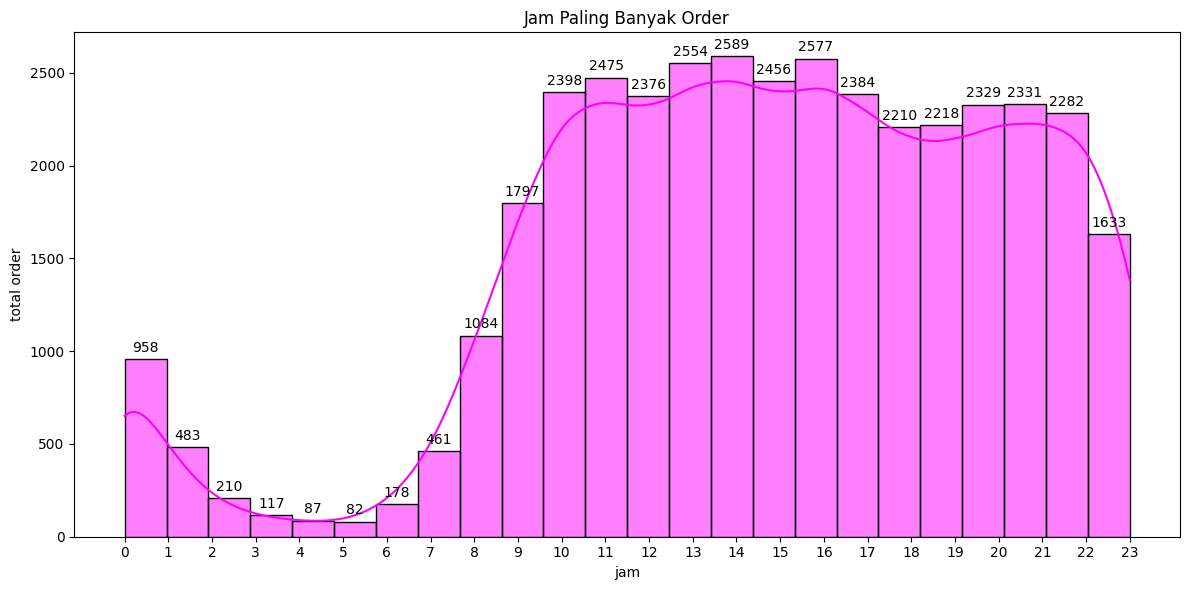

In [158]:
#jam paling banyak order

df['jam'] = df['order_purchase_timestamp'].dt.hour

plt.figure(figsize = (12,6))
ax = sns.histplot(df['jam'], bins = 24, kde = True, color = 'magenta')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Jam Paling Banyak Order')
plt.xlabel('jam')
plt.ylabel('total order')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [159]:
#trend penjualan perbulan

df['monthly'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M').astype(str)

bulanan = df.groupby('monthly')['payment_value'].sum().reset_index()
bulanan

,monthly,payment_value
0,2016-10,33233.89
1,2016-12,351.69
2,2017-01,92384.75
3,2017-02,167064.16
4,2017-03,273362.52
5,2017-04,258512.87
6,2017-05,373070.85
7,2017-06,326908.57
8,2017-07,430371.50
9,2017-08,494233.65


In [160]:
#persentase kontribusi setiap state
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending= False).reset_index()
total_state_revenue = state_revenue['payment_value'].sum()
state_revenue['kontribusi'] = (state_revenue['payment_value'] / total_state_revenue) * 100  
state_revenue

,customer_state,payment_value,kontribusi
0,SP,4246217.72,41.459372
1,RJ,1389494.31,13.566794
2,MG,1209901.17,11.813276
3,RS,589910.96,5.759794
4,PR,500394.37,4.885768
5,SC,377914.82,3.689898
6,BA,326944.31,3.192231
7,DF,236470.91,2.308863
8,GO,204953.28,2.001130
9,ES,190458.93,1.859610


In [161]:
# kontribusi city per state

city = df.groupby(['customer_city', 'customer_state'])['payment_value'].sum().sort_values(ascending= 0).reset_index()
city['total_per_state'] = city.groupby('customer_state')['payment_value'].transform('sum')
city['kontribusi'] = (city['payment_value'] / city['total_per_state'])*100
city

,customer_city,customer_state,payment_value,total_per_state,kontribusi
0,sao paulo,SP,1620969.59,4246217.72,38.174434
1,rio de janeiro,RJ,774796.16,1389494.31,55.761017
2,belo horizonte,MG,300650.48,1209901.17,24.849177
3,brasilia,DF,233170.03,236470.91,98.604107
4,curitiba,PR,163674.94,500394.37,32.709189
...,...,...,...,...,...
2888,serra branca,PB,0.91,55056.32,0.001653
2889,iacri,SP,0.81,4246217.72,0.000019
2890,bernardino de campos,SP,0.80,4246217.72,0.000019
2891,pedra branca,CE,0.54,143071.45,0.000377


In [162]:
# top 10 customer
best_customer =  df.groupby('customer_id')['payment_value'].sum().sort_values(ascending=0)
best_customer.head(10)

customer_id
af7UwM4ENx7y    13664.08
XGV9MaVUAqRE    13664.08
JZaXOh5MFNsP     7274.88
zAIIzzxbldYn     6929.31
AsgIeZapKCVB     6922.21
Oc4P8O8m921E     6922.21
tEAu5bO4GiaB     6922.21
fILwKNWvsVBj     6922.21
SBrXA9joWBl1     6922.21
twLFhZ00vYqi     6081.54
Name: payment_value, dtype: float64

In [163]:
#Total Pendapatan per Metode Pembayaran 
tipe_pembayaran = df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=0).reset_index()
tipe_pembayaran

,payment_type,payment_value
0,credit_card,7510997.24
1,wallet,1963564.46
2,voucher,637150.09
3,debit_card,130164.83


In [164]:
#state x shipping charged
shipping = df.groupby('customer_state')['shipping_charges'].mean().sort_values(ascending=0).reset_index().round(2)
shipping.index = shipping.index + 1
shipping

,customer_state,shipping_charges
1,AP,51.54
2,PA,49.87
3,RO,49.77
4,CE,48.75
5,AM,48.10
6,MS,48.01
7,BA,47.80
8,PE,47.66
9,PI,46.89
10,TO,46.21


In [165]:
#best seller
best_seller = df.groupby('seller_id')['payment_value'].sum().sort_values(ascending=0).reset_index()
best_seller.index = best_seller.index +1
best_seller.head(10)

,seller_id,payment_value
1,yGbPyLPc8PmT,211247.32
2,r7VxefoTVHbb,204152.89
3,RKad98cTxhSb,167700.26
4,TuPm19CMKvrM,154668.87
5,K0qPVGdA91KO,131555.54
6,ruq0u2ZpAMDr,129388.31
7,EGW4UK5bOeEZ,125458.04
8,l1pYW6GBnPMr,123187.60
9,UOGIrJtSldvd,111685.47
10,YVBAT3QqF9Qj,104627.60


In [166]:
df_monthly_inst = df.groupby('monthly')['payment_installments'].mean()
df_monthly_inst

monthly
2016-10    4.088496
2016-12    1.000000
2017-01    3.207207
2017-02    2.918552
2017-03    2.986730
2017-04    3.085271
2017-05    3.523614
2017-06    3.230210
2017-07    3.207370
2017-08    3.266553
2017-09    3.068966
2017-10    2.965608
2017-11    3.208817
2017-12    2.956974
2018-01    2.687614
2018-02    2.785821
2018-03    2.955696
2018-04    2.762140
2018-05    2.906853
2018-06    2.957131
2018-07    2.822710
2018-08    2.852411
2018-09    1.000000
Name: payment_installments, dtype: float64

In [167]:
#top product
top_product = df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=0).reset_index()
top_product.index = top_product.index + 1
top_product.head(10)

,product_category_name,payment_value
1,toys,7660871.28
2,bed_bath_table,260316.45
3,health_beauty,240843.93
4,sports_leisure,216139.40
5,furniture_decor,211182.15
6,computers_accessories,196711.60
7,housewares,169736.99
8,watches_gifts,151762.51
9,garden_tools,106111.46
10,cool_stuff,102302.96


In [168]:
#K-Means to Identify Payment Installment Patterns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['payment_installments','price']].copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters= 3, random_state= 42 , n_init= 10)
df['cluster_cicilan'] = kmeans.fit_predict(x_scaled)

summary = df.groupby('cluster_cicilan')[['payment_installments', 'price']].mean().reset_index()
summary.index = summary.index + 1
summary

,cluster_cicilan,payment_installments,price
1,0,1.654093,239.364444
2,1,7.633593,236.579706
3,2,2.665334,2499.769543


In [169]:
barang = df.groupby('payment_installments')['price'].mean().sort_values(ascending=0).reset_index()
barang.index = barang.index + 1
barang

,payment_installments,price
1,14,521.445000
2,18,402.667500
3,12,375.658776
4,7,365.786827
5,6,360.413342
6,4,355.546728
7,1,349.452279
8,2,343.934354
9,5,343.201776
10,3,330.490605


C:\Users\belzs\AppData\Local\Temp\ipykernel_13336\1296654337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='payment_installments', y='price', palette='viridis')


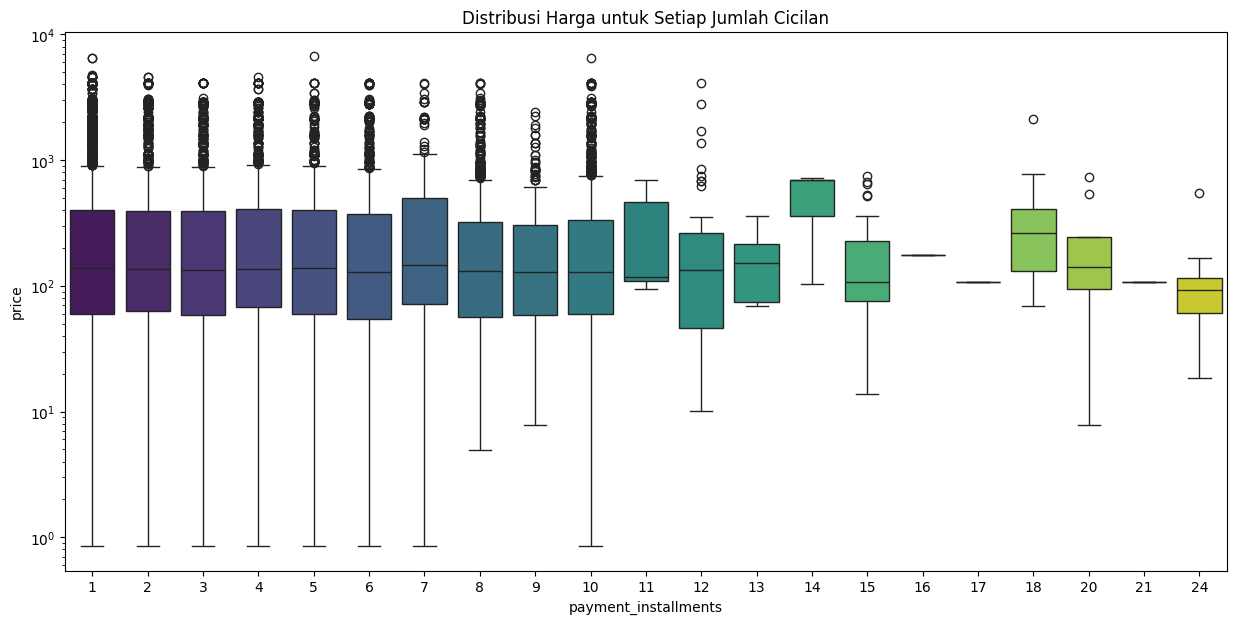

In [170]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='payment_installments', y='price', palette='viridis')
plt.yscale('log') # Gunakan skala log jika perbedaan harga sangat ekstrem
plt.title('Distribusi Harga untuk Setiap Jumlah Cicilan')
plt.show()

In [171]:
correlation = df['price'].corr(df['payment_installments'])
correlation

-0.02084547164420897

In [172]:
df['monthly_installment_value'] = df['price'] / df['payment_installments']
angsuran_bulan = df.groupby('customer_state')['monthly_installment_value'].mean().sort_values(ascending=0).reset_index()

C:\Users\belzs\AppData\Local\Temp\ipykernel_13336\2612286630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= angsuran_bulan, x= 'customer_state', y= 'monthly_installment_value', palette= 'coolwarm')


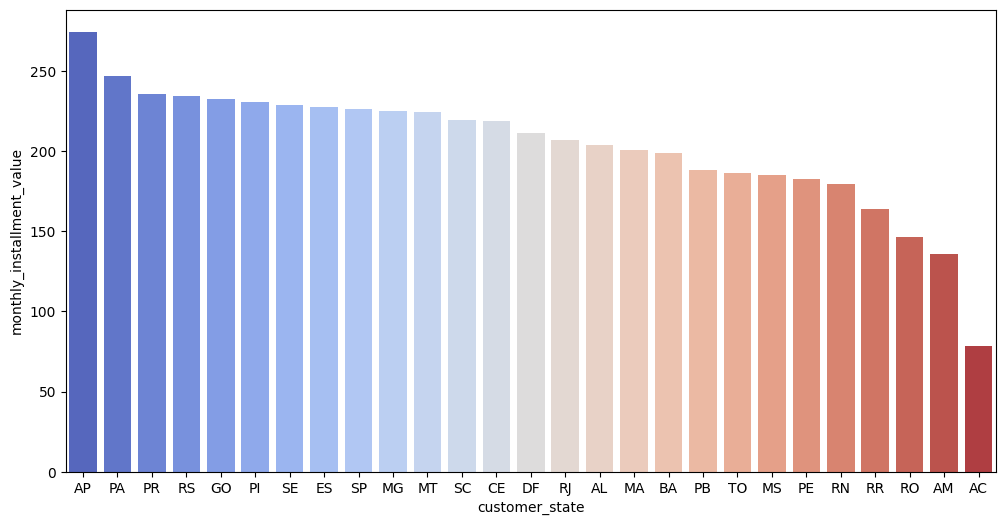

In [173]:
plt.figure(figsize=(12,6))
sns.barplot(data= angsuran_bulan, x= 'customer_state', y= 'monthly_installment_value', palette= 'coolwarm')
plt.show()

In [174]:
#aov 
order_total = df.groupby(['order_id', 'customer_state'])['payment_value'].sum().reset_index()
aov = order_total.groupby('customer_state')['payment_value'].mean().sort_values(ascending= 0).reset_index()
aov.index = aov.index +1
aov

,customer_state,payment_value
1,AL,319.810000
2,AM,312.953077
3,MA,309.591291
4,AP,303.340000
5,CE,303.117479
6,RN,293.936995
7,PB,282.340103
8,TO,280.735000
9,PI,280.206011
10,DF,280.178803


In [175]:
repeat_customer = df.groupby('customer_id')['order_id'].nunique().reset_index()
repeat_customer.columns = ['customer_id', 'order_count']

churned = repeat_customer[repeat_customer['order_count'] == 1].shape[0]
total_customer = repeat_customer.shape[0]

churn_rate =(churned/total_customer)*100
churn_rate

100.0

In [176]:
#korelasi berat atau volume mempengaruhi shipping charges

volume = df['product_length_cm'] * df['product_height_cm'] *df['product_width_cm']
volume

a = df['shipping_charges'].corr(volume)

b = df['shipping_charges'].corr(df['product_weight_g']).round(4)

print(a)
print(b)

0.0207173746941005
0.0186


10:07:07 - cmdstanpy - INFO - Chain [1] start processing
10:07:07 - cmdstanpy - INFO - Chain [1] done processing


Hasil Prediksi 30 Hari ke Depan:
            ds       yhat  yhat_lower  yhat_upper
637 2018-09-29  53.210462   24.345237   80.616715
638 2018-09-30  56.706152   28.650349   83.875513
639 2018-10-01  77.397285   49.770890  102.115837
640 2018-10-02  77.271914   49.326016  101.467102
641 2018-10-03  76.100951   47.991800  101.455598


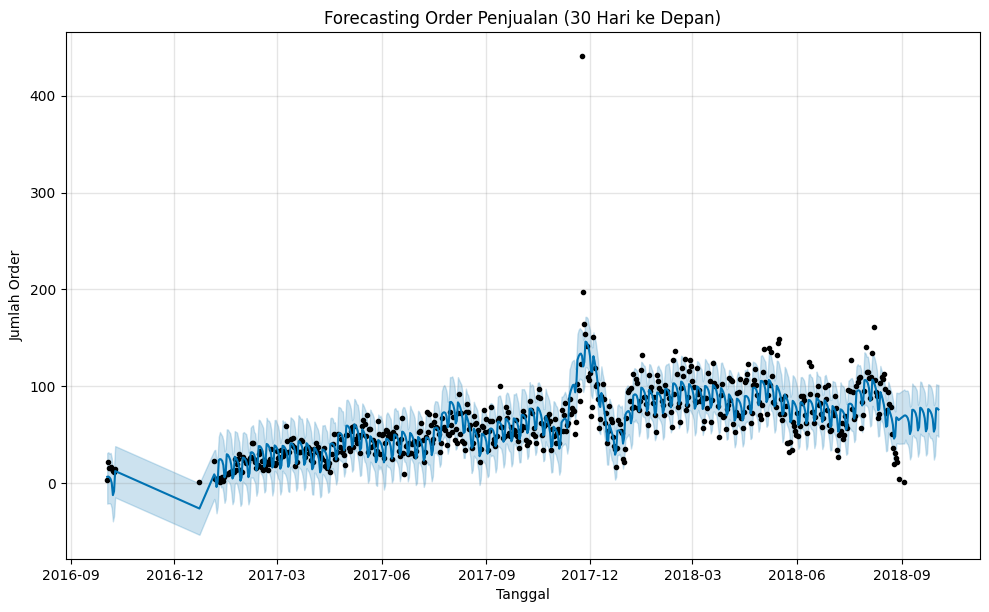

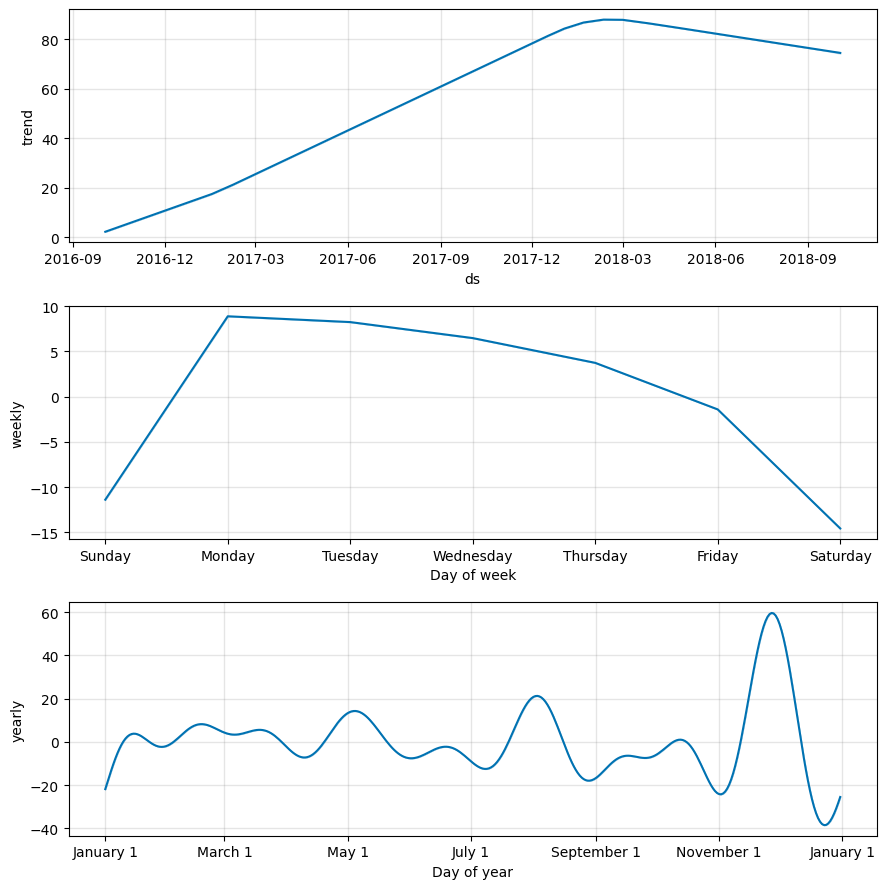

In [ ]:
#analisis time series menggunakan Prophet
df_ts = df.copy()
daily_orders = df_ts.groupby(df_ts['order_purchase_timestamp'].dt.date).size().reset_index()
daily_orders.columns = ['ds', 'y']
daily_orders['ds'] = pd.to_datetime(daily_orders['ds'])
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False
)
model.fit(daily_orders)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
print("Hasil Prediksi 30 Hari ke Depan:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

fig1 = model.plot(forecast)
plt.title('Forecasting Order Penjualan (30 Hari ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Order')
plt.show()
fig2 = model.plot_components(forecast)
plt.show()